In [1]:
from dotenv import load_dotenv
import os
load_dotenv("../.env") 
MONGO_URI = os.getenv("MONGO_URI")
from pymongo import MongoClient
import pandas as pd
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue,origin
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,[politique],negatif,rss,2026-01-20 05:36:32,-0.422936,fr,Madagascar Tribune
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,[politique],positif,rss,2026-01-20 05:31:21,0.479494,fr,Madagascar Tribune
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,[politique],positif,rss,2026-01-19 05:35:00,0.349573,fr,Madagascar Tribune
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,[politique],negatif,rss,2026-01-19 05:00:00,-0.411597,fr,Madagascar Tribune
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,[politique],negatif,rss,2026-01-19 04:00:00,-0.360593,fr,Madagascar Tribune


In [2]:
print("Total articles:", len(df))
print(df.info())
print(df.isna().sum())

Total articles: 2296
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296 entries, 0 to 2295
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   _id               2296 non-null   object        
 1   id_article        2296 non-null   object        
 2   source            2296 non-null   object        
 3   titre             2296 non-null   object        
 4   date_publication  2296 non-null   datetime64[ns]
 5   contenu           2296 non-null   object        
 6   url               2296 non-null   object        
 7   categorie         2296 non-null   object        
 8   sentiment         2296 non-null   object        
 9   source_type       2296 non-null   object        
 10  created_at        2296 non-null   object        
 11  sentiment_score   2296 non-null   float64       
 12  langue            2296 non-null   object        
 13  origin            2296 non-null   object        
dtypes: 

In [3]:
from collections import Counter
types = Counter()

for doc in collection.find({}, {"date_publication": 1}):
    value = doc.get("date_publication")
    types[type(value).__name__] += 1

print(types)

Counter({'datetime': 2296})


In [4]:
df = pd.DataFrame(list(collection.find()))
print("Total documents :", len(df))

Total documents : 2296


In [37]:
invalid_df = df[df[["titre", "contenu"]].isna().any(axis=1)]

print("Documents invalides :", len(invalid_df))
invalid_df.head()

Documents invalides : 0


,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue


In [76]:
from dateutil import parser
from datetime import datetime

for doc in collection.find({"date_publication": {"$type": "string"}}):
    try:
        new_date = parser.parse(doc["date_publication"])
        
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {"date_publication": new_date}}
        )
    except Exception as e:
        print(f"Erreur sur {doc['_id']} : {doc['date_publication']}")


In [25]:
ids_to_delete = invalid_df["_id"].tolist()

print("IDs à supprimer :", len(ids_to_delete))

IDs à supprimer : 27


In [26]:
result = collection.delete_many({"_id": {"$in": ids_to_delete}})

print("Documents supprimés dans Mongo :", result.deleted_count)

Documents supprimés dans Mongo : 27


In [27]:
df = df.dropna(subset=["titre", "contenu"])

print("DataFrame nettoyé :", len(df))

DataFrame nettoyé : 2212


In [28]:
print(df[["titre","contenu"]].isna().sum())

titre      0
contenu    0
dtype: int64


In [65]:
MIN_CONTENT_LENGTH = 30

short_content = df[df["contenu"].str.len() < MIN_CONTENT_LENGTH]

print("📌 Nombre de contenus trop courts :", len(short_content))

📌 Nombre de contenus trop courts : 0


In [30]:
short_content[["titre", "contenu"]].head(10)

,titre,contenu
414,LETTRE OUVERTE À MONSIEUR LE PRÉSIDENT DE LA R...,"LETTRE OUVERTE ,2026"
1879,Nécrologie du 27 février 2026,Cliquez pour agrandir
2212,RTA : Replay Auto-Moto 4/2 du 22 FEVRIER 2026,rt@
2213,RTA : Replay Auto-Moto 4/2 du 15 FEVRIER 2026,rt@


In [5]:
df["contenu_length"] = df["contenu"].str.len()

df["contenu_length"].describe()

count     2296.000000
mean      1193.988240
std       1186.541022
min        103.000000
25%        479.000000
50%        531.000000
75%       1801.000000
max      10748.000000
Name: contenu_length, dtype: float64

In [32]:
MIN_CONTENT_LENGTH = 30

# 1️⃣ Trouver les contenus trop courts
short_content = df[df["contenu"].str.len() < MIN_CONTENT_LENGTH]

print("📌 Articles avec contenu trop court :", len(short_content))

# 2️⃣ Récupérer les _id
ids_to_delete = short_content["_id"].tolist()

# 3️⃣ Supprimer dans MongoDB
result = collection.delete_many({"_id": {"$in": ids_to_delete}})

print("🗑 Supprimés dans MongoDB :", result.deleted_count)

# 4️⃣ Supprimer dans le DataFrame
df = df[df["contenu"].str.len() >= MIN_CONTENT_LENGTH]

print("✅ DataFrame restant :", len(df))

📌 Articles avec contenu trop court : 4
🗑 Supprimés dans MongoDB : 4
✅ DataFrame restant : 2208


In [16]:
collection.delete_many({
    "$or": [
        {"titre": ""},
        {"titre": None},
        {"titre": {"$regex": r"^\s*$"}}
    ]
})


DeleteResult({'n': 1, 'electionId': ObjectId('7fffffff000000000000003d'), 'opTime': {'ts': Timestamp(1772108578, 2), 't': 61}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1772108578, 2), 'signature': {'hash': b'\xf2\xa9\xbds\x81\xb7\x81\xd8$#st\x1e,\x8b\xa1\xae\xf0=V', 'keyId': 7573748671250956292}}, 'operationTime': Timestamp(1772108578, 2)}, acknowledged=True)

In [31]:
from pymongo import UpdateOne

# Listes de référence
RSS_FEEDS = [
    "https://www.madagascar-tribune.com/spip.php?page=backend",
    "https://www.lexpress.mg/feeds/posts/default",
    "https://newsmada.com/feed/",
    "https://midi-madagasikara.mg/feed/",  
    "https://2424.mg/feed/",
    "https://rsf.org/fr/rss/afrique/madagascar/feed.xml",
    "https://www.madagate.org/index.php?format=feed&type=rss",
    "https://lgdi-madagascar.com/feed/",
    "https://midi-madagasikara.mg/category/politique/feed/",
    "https://midi-madagasikara.mg/category/economie/feed/",
    "https://www.lexpress.mg/feeds/posts/default/-/Politique",
    "https://www.lexpress.mg/feeds/posts/default/-/%C3%89conomie",
    "https://newsmada.com/category/les-nouvelles/feed/",
    "https://newsmada.com/category/les-nouvelles/politique/feed/",
    "https://2424.mg/category/actualite/politique/feed/",
    "https://2424.mg/category/actualite/economie/feed/",
    "https://www.lemonde.fr/madagascar/rss_full.xml",
    "https://www.courrierinternational.com/feed/rubrique/madagascar/rss.xml",
    "https://news.google.com/rss/search?q=Madagascar&hl=fr&gl=FR&ceid=FR:fr",
    "https://tanikomadagascar.com/feed/",
    "https://namana-studio.fr/feed/",
    "https://www.youtube.com/feeds/videos.xml?channel_id=UCK84qSI2bEMWkX9vUptkAlA"
]

SCRAP_HTML_SOURCES = ["Malagasy News"]
SCRAP_SELENIUM_SOURCES = ["Orange Actu"]

operations = []

# Parcourir uniquement les docs où source_type est vide ou None
for doc in collection.find({"$or": [{"source_type": {"$exists": False}}, {"source_type": None}, {"source_type": ""}]}):
    source = (doc.get("source") or "").strip()
    source_type = None

    # Vérifier RSS
    if any(source.startswith(rss) for rss in RSS_FEEDS):
        source_type = "rss"
    # Vérifier SCRAP_HTML
    elif any(source.startswith(scrap) for scrap in SCRAP_HTML_SOURCES):
        source_type = "scrap_html"
    # Vérifier SCRAP_SELENIUM
    elif any(scrap in source for scrap in SCRAP_SELENIUM_SOURCES):
        source_type = "scrap_selenium"
    # fallback
    else:
        source_type = "inconnu"

    operations.append(
        UpdateOne(
            {"_id": doc["_id"]},
            {"$set": {"source_type": source_type}}
        )
    )

# Exécution batch
if operations:
    result = collection.bulk_write(operations)
    print(f"Documents mis à jour avec source_type : {result.modified_count}")
else:
    print("Aucun document vide à mettre à jour")



Aucun document vide à mettre à jour


In [6]:
result = collection.aggregate([
    {"$group": {"_id": "$source_type", "count": {"$sum": 1}}}
])

for r in result:
    print(r)

{'_id': 'scrap_selenium', 'count': 68}
{'_id': 'rss', 'count': 2198}
{'_id': 'scrap_html', 'count': 30}


In [19]:
from pymongo import MongoClient
import pandas as pd
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]
data = list(collection.find())
df = pd.DataFrame(data)

df.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,[politique],neutre,rss,2026-01-20 05:36:32,0.05000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,[politique],neutre,rss,2026-01-20 05:31:21,0.19375,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,[autre],negatif,rss,2026-01-19 05:35:00,-0.40000,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,[politique],neutre,rss,2026-01-19 05:00:00,0.20000,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,[politique],neutre,rss,2026-01-19 04:00:00,0.00000,fr


In [33]:
from pymongo import UpdateOne

operations = []

# Parcourir uniquement les documents où created_at est vide ou None
for doc in collection.find({"$or": [{"created_at": {"$exists": False}}, {"created_at": None}, {"created_at": ""}]}):
    date_pub = doc.get("date_publication")
    
    if date_pub:  # on ne copie que si date_publication existe
        operations.append(
            UpdateOne(
                {"_id": doc["_id"]},
                {"$set": {"created_at": date_pub}}
            )
        )

# Exécution batch
if operations:
    result = collection.bulk_write(operations)
    print(f"Documents mis à jour avec created_at : {result.modified_count}")
else:
    print("Aucun document vide à mettre à jour")


Aucun document vide à mettre à jour


In [34]:
result = collection.aggregate([
     {"$group": {"_id": "$created_at", "count": {"$sum": 1}}}
])

for r in result:
    print(r)

{'_id': datetime.datetime(2026, 1, 23, 2, 35, 0, 1000), 'count': 1}
{'_id': datetime.datetime(2026, 1, 14, 5, 25, 15), 'count': 1}
{'_id': datetime.datetime(2026, 1, 21, 6, 11), 'count': 1}
{'_id': '2026-02-12T16:31:14.559270', 'count': 1}
{'_id': datetime.datetime(2026, 1, 20, 2, 40), 'count': 1}
{'_id': '2026-02-12T16:31:14.561559', 'count': 1}
{'_id': '2026-02-19T09:48:40.690298', 'count': 1}
{'_id': datetime.datetime(2025, 12, 31, 13, 0, 10), 'count': 1}
{'_id': '2026-02-17T08:35:33.616503', 'count': 1}
{'_id': '2026-02-16T15:12:45.493555', 'count': 1}
{'_id': datetime.datetime(2025, 12, 8, 9, 10, 14), 'count': 1}
{'_id': '2026-02-17T08:36:33.058392', 'count': 1}
{'_id': '2026-02-13T08:41:48.346899', 'count': 1}
{'_id': '2026-02-17T08:46:55.691282', 'count': 1}
{'_id': datetime.datetime(2026, 1, 27, 19, 2, 15), 'count': 1}
{'_id': datetime.datetime(2026, 1, 22, 4, 41, 43), 'count': 1}
{'_id': datetime.datetime(2026, 1, 27, 2, 50, 0, 1000), 'count': 1}
{'_id': datetime.datetime(2026

In [12]:
print(df["date_publication"].dtype)
df["date_publication"].head()

object


0    2026-01-20 05:36:32
1    2026-01-20 05:31:21
2    2026-01-19 05:35:00
3    2026-01-19 05:00:00
4    2026-01-19 04:00:00
Name: date_publication, dtype: object

In [20]:
import pandas as pd

df["date_publication"] = pd.to_datetime(
    df["date_publication"],
    errors="coerce"
)

print(df["date_publication"].dtype)
print("NaT :", df["date_publication"].isna().sum())

object
NaT : 0


C:\Users\nombaina\AppData\Local\Temp\ipykernel_15436\3520933027.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date_publication"] = pd.to_datetime(


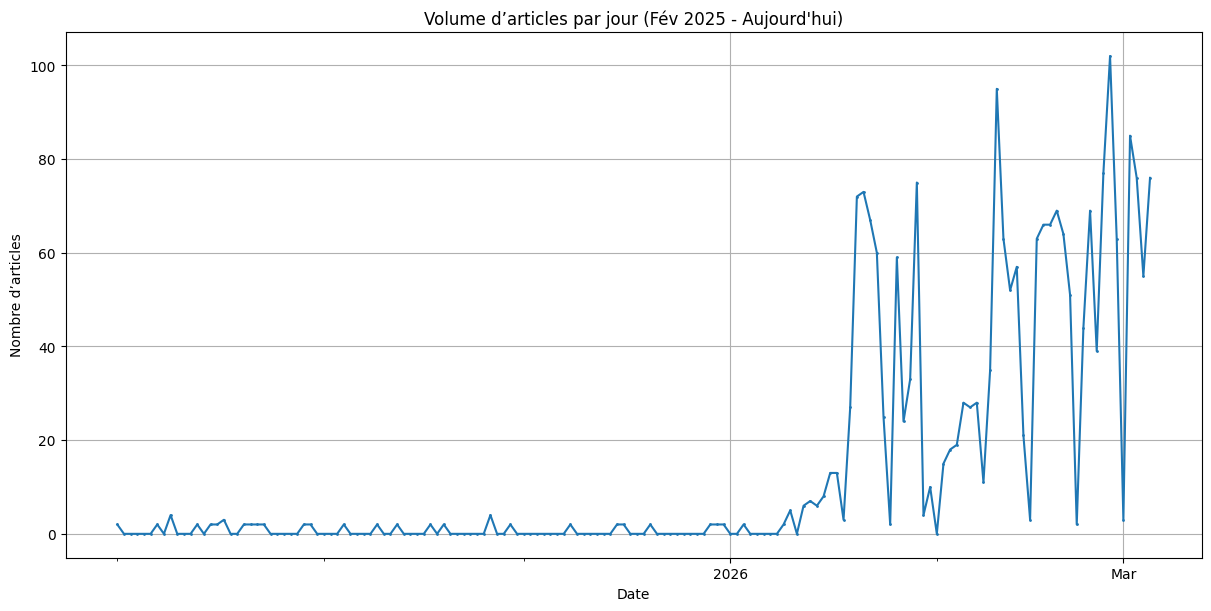

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assurer que date_publication est datetime UTC
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce", utc=True)

# Filtrer à partir du 1er février 2025
start_date = pd.Timestamp("2025-10-01", tz="UTC")
end_date = pd.Timestamp.now(tz="UTC")
df_filtre = df[df["date_publication"] >= start_date]

# Grouper par jour
volume_jour = df_filtre.groupby(df_filtre["date_publication"].dt.normalize()).size()

# Reindex pour inclure tous les jours jusqu'à aujourd'hui
all_dates = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")
volume_jour = volume_jour.reindex(all_dates, fill_value=0)

# --- Création du graphique ---
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')

ax.plot(volume_jour.index, volume_jour.values, marker='o', markersize=1, linestyle='-')

# Major ticks every 6 months, minor ticks every month
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,3)))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Utilisation d'un ConciseDateFormatter pour plus de clarté
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.set_title("Volume d’articles par jour (Fév 2025 - Aujourd'hui)")
ax.set_xlabel("Date")
ax.set_ylabel("Nombre d’articles")
ax.grid(True)

plt.show()

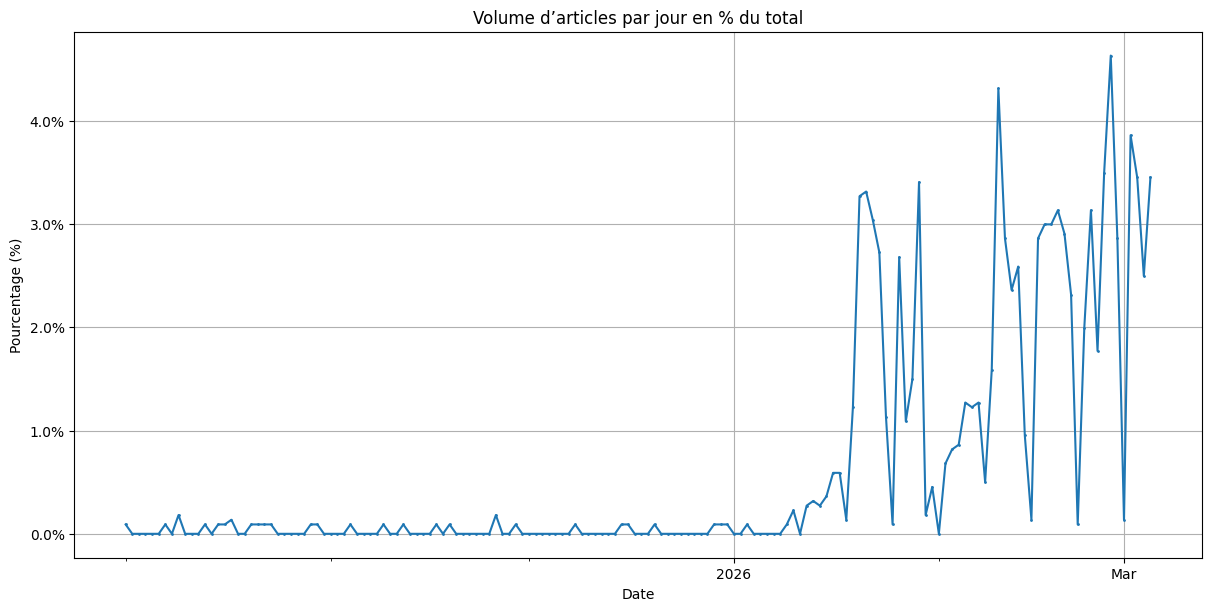

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# Assurer que date_publication est datetime UTC
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce", utc=True)

# Filtrer à partir du 1er octobre 2025
start_date = pd.Timestamp("2025-10-01", tz="UTC")
end_date = pd.Timestamp.now(tz="UTC")
df_filtre = df[df["date_publication"] >= start_date]

# Grouper par jour
volume_jour = df_filtre.groupby(df_filtre["date_publication"].dt.normalize()).size()

# Reindex pour inclure tous les jours jusqu'à aujourd'hui
all_dates = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")
volume_jour = volume_jour.reindex(all_dates, fill_value=0)

# --- Conversion en pourcentage du total ---
volume_percent = volume_jour / df_filtre.shape[0]  # proportion (0 à 1)

# --- Création du graphique ---
fig, ax = plt.subplots(figsize=(12,6), layout='constrained')

ax.plot(volume_percent.index, volume_percent.values, marker='o', markersize=1, linestyle='-')

# Formatter l'axe Y en pourcentage
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 car les valeurs vont de 0 à 1

# Major ticks every 6 months, minor ticks every month
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1,3)))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.set_title("Volume d’articles par jour en % du total")
ax.set_xlabel("Date")
ax.set_ylabel("Pourcentage (%)")
ax.grid(True)

plt.show()

In [9]:
df = pd.DataFrame(list(collection.find()))
print(df["categorie"].head())

0    [politique]
1    [politique]
2    [politique]
3    [politique]
4    [politique]
Name: categorie, dtype: object


In [10]:
df_exploded = df.explode("categorie")
print(df_exploded["categorie"].head())

0    politique
1    politique
2    politique
3    politique
4    politique
Name: categorie, dtype: object


In [16]:
df_exploded.head()

,_id,id_article,source,titre,date_publication,contenu,url,categorie,sentiment,source_type,created_at,sentiment_score,langue
0,696f6450803a3bd1d5076f9f,https://www.madagascar-tribune.com/Conjoncture...,https://www.madagascar-tribune.com/spip.php?pa...,Richard Ravalomanana et Marie Michelle Sahondr...,2026-01-20 05:36:32,Deux figures emblématiques du régime Rajoelina...,https://www.madagascar-tribune.com/Conjoncture...,politique,neutre,rss,2026-01-20 05:36:32,0.05000,fr
1,696f6450803a3bd1d5076fa0,https://www.madagascar-tribune.com/Senat-la-HC...,https://www.madagascar-tribune.com/spip.php?pa...,Sénat : la HCC confirme la fin du mandat et l'...,2026-01-20 05:31:21,La Haute Cour constitutionnelle (HCC) a offici...,https://www.madagascar-tribune.com/Senat-la-HC...,politique,neutre,rss,2026-01-20 05:31:21,0.19375,fr
2,696f6451803a3bd1d5076fa1,https://www.madagascar-tribune.com/103-signatu...,https://www.madagascar-tribune.com/spip.php?pa...,103 poids plume,2026-01-19 05:35:00,Lors d'« Assises des Partis Politiques » pour ...,https://www.madagascar-tribune.com/103-signatu...,autre,negatif,rss,2026-01-19 05:35:00,-0.40000,fr
3,696f6451803a3bd1d5076fa2,https://www.madagascar-tribune.com/Concertatio...,https://www.madagascar-tribune.com/spip.php?pa...,Concertation nationale : le président de la Re...,2026-01-19 05:00:00,Le colonel Randrianarina est venu à la rescous...,https://www.madagascar-tribune.com/Concertatio...,politique,neutre,rss,2026-01-19 05:00:00,0.20000,fr
4,696f6451803a3bd1d5076fa3,https://www.madagascar-tribune.com/Administrat...,https://www.madagascar-tribune.com/spip.php?pa...,Herintsalama Rajaonarivelo ferme la porte à un...,2026-01-19 04:00:00,"Ce dimanche, devant des milliers de fidèles de...",https://www.madagascar-tribune.com/Administrat...,politique,neutre,rss,2026-01-19 04:00:00,0.00000,fr


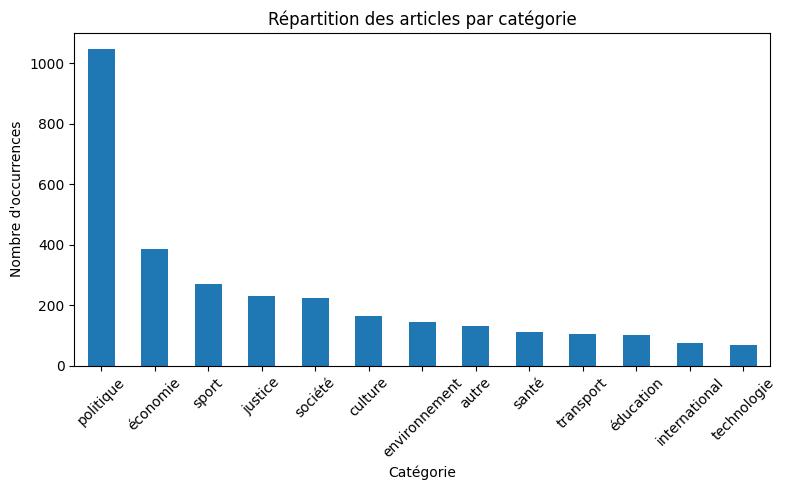

In [11]:
import matplotlib.pyplot as plt

volume_cat = df_exploded["categorie"].value_counts()

plt.figure(figsize=(8,5))
volume_cat.plot(kind="bar")

plt.title("Répartition des articles par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

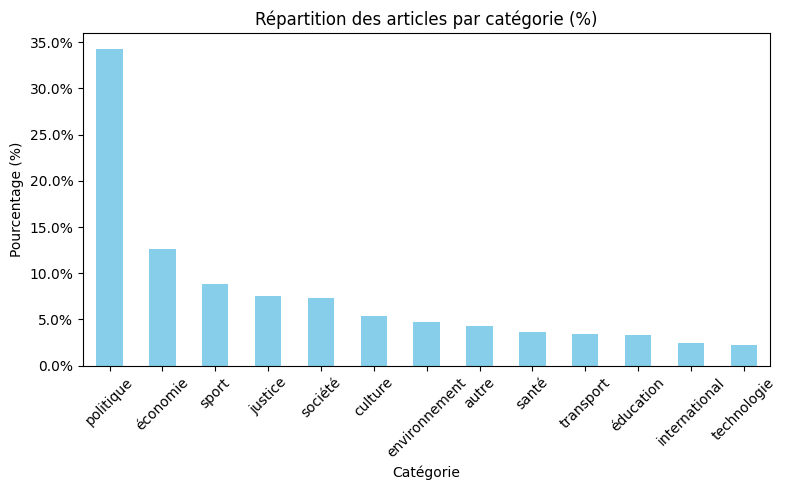

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# volume par catégorie
volume_cat = df_exploded["categorie"].value_counts()

# --- Conversion en pourcentage du total ---
volume_cat_percent = volume_cat / volume_cat.sum()  # valeurs 0 → 1

# --- Graphique ---
plt.figure(figsize=(8,5))
ax = volume_cat_percent.plot(kind="bar", color="skyblue")

# Formatter axe Y en %
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 car valeurs entre 0 et 1

plt.title("Répartition des articles par catégorie (%)")
plt.xlabel("Catégorie")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
result = collection.delete_many({
     "source": "https://tanikomadagascar.com/feed/"
})

print("Nombre d'articles supprimés :", result.deleted_count)

Nombre d'articles supprimés : 68


In [54]:
import re
import unicodedata
from bs4 import BeautifulSoup
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer
from sentence_transformers import SentenceTransformer, util
import torch
from collections import Counter
from transformers import pipeline

DetectorFactory.seed = 0
tb_fr = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

SIMILARITY_THRESHOLD = 0.30

fr_sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

def clean_text(html_text: str) -> str:
    """Nettoie le HTML pour ne garder que le texte brut."""
    if not html_text:
        return ""
    soup = BeautifulSoup(html_text, "html.parser")
    text = soup.get_text(separator=" ")
    text = unicodedata.normalize("NFKC", text)
    return " ".join(text.split())

def normalize_text(text: str) -> str:
    if not text:
        return ""

    soup = BeautifulSoup(text, "html.parser")
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = re.sub(r"[^\w\s]", " ", text)
    return " ".join(text.split())

malagasy_words = {
    # ===== PRONOMS & MOTS COURANTS =====
    "izy", "anao", "aho", "isika", "ianao", "izy ireo", "izany", "ity", "ireo",
    "eto", "any", "amin", "amin'ny", "ao", "ary", "na", "fa", "raha", "satria",

    # ===== SOCIETE / ADMINISTRATION =====
    "firenena", "tanora", "mponina", "sekoly", "mpianatra",
    "governemanta", "ministera", "ben'ny tanàna", "ben ny tanana",
    "depiote", "depute", "filoha", "antoko politika",
    "lalàm-panorenana", "lalampanorenana",
    "repoblika", "kaominina", "prefe", "distrika",
    "mpitondra", "fitondrana", "biraom-panjakana",

    # ===== VIE QUOTIDIENNE =====
    "trano", "làlana", "lalana", "fianakaviana",
    "asa", "vidim-piainana", "vidimpiainana",
    "fampandrosoana", "fiainana", "vahoaka",
    "zaza", "reny", "ray",

    # ===== ECONOMIE / COMMERCE =====
    "toekarena", "varotra", "orinasa", "tsena",
    "banky", "fampiasam-bola", "fampiasambola",
    "hetra", "karama", "vola", "tetibola",
    "fividianana", "fanondranana", "fanondranana entana",

    # ===== SANTE =====
    "fahasalamana", "hopitaly", "hôpitaly",
    "dokoterà", "dokotera", "aretina",
    "vaksiny", "fanafody", "marary",
    "valanaretina", "hopital",

    # ===== EDUCATION =====
    "fanabeazana", "oniversite", "universite",
    "mpampianatra", "kilasy", "sekoly ambony",
    "mpianatra", "fampianarana",

    # ===== SPORT =====
    "baolina kitra", "lalao", "ekipa",
    "fifaninanana", "mpilalao", "stadiona",

    # ===== TECHNOLOGIE =====
    "haitao", "siansa", "fikajiana",
    "rindranasa", "aterineto", "tambajotra",
    "finday", "solosaina",

    # ===== ENVIRONNEMENT =====
    "tontolo iainana", "toetrandro",
    "fandotoana", "ala", "rano",
    "rivodoza", "hain-tany",

    # ===== INTERNATIONAL =====
    "iraisam-pirenena", "ady",
    "fifandraisana iraisam-pirenena",
    "firaisankina", "diplomasia",

    # ===== JUSTICE =====
    "heloka", "fitsarana",
    "mpisolovava", "polisy",
    "fonja", "lalàna", "lalana",

    # ===== TRANSPORT =====
    "fitaterana", "seranam-piaramanidina",
    "taxi-be", "taxibe",
    "bus", "fiara", "sambo",

    # ===== MEDIAS / ACTUALITE =====
    "vaovao", "gazety", "fampitam-baovao",
    "mpanao gazety", "tatitra",
    "fanambarana", "lahateny"
}

malagasy_words_set = set(malagasy_words)
_lang_cache = {}
    
def detect_language(text: str, min_mg_ratio: float = 0.15) -> str:
    """
    Détecte la langue : soit 'mg' pour malgache, soit 'fr' pour français.
    Priorité au malgache via dictionnaire.
    """

    if not text or len(text.strip()) < 5:
        return "fr"  # par défaut, considérer FR si texte trop court

    # cache
    if text in _lang_cache:
        return _lang_cache[text]

    clean = normalize_text(text)
    words = clean.split()

    if not words:
        _lang_cache[text] = "fr"
        return "fr"

    # ✅ Vérifier ratio de mots malgaches
    mg_count = sum(1 for w in words if w in malagasy_words_set)
    mg_ratio = mg_count / len(words)

    if mg_ratio >= min_mg_ratio:
        _lang_cache[text] = "mg"
        return "mg"

    # sinon fallback langdetect
    try:
        lang = detect(text)
        result = "fr" if lang == "fr" else "mg"  # on force à l'un ou l'autre
    except LangDetectException:
        result = "fr"  # par défaut

    _lang_cache[text] = result
    return result
        
_sentiment_cache = {}

mg_positive_words = {
    # émotions positives
    "faly", "hafaliana", "ravoravo", "mientanentana", "fiononana", "tsapako ny hafaliana",
    "finaritra", "tahamaina",

    # qualité / appréciation
    "tsara", "tena tsara", "mahafinaritra", "mendrika",
    "mahafa-po", "mety", "ara-dalàna", "tsara tarehy", "mahatalanjona",
    "miavaka", "mahasoa", "mankasitraka",

    # réussite / progrès
    "fandrosoana", "fampandrosoana", "nahomby", "fahombiazana",
    "fanatsarana", "fanarenana", "fitomboana", "tombony",
    "fanavaozana", "fampivoarana", "fahavitrihana", "voavaha ny olana",

    # soutien / accord
    "mankasitraka", "fanohanana", "mirary soa",
    "firaisankina", "fandriampahalemana", "miara-miasa", "fampanantenana",

    # stabilité / sécurité
    "milamina", "filaminana", "voavaha", "vahaolana",
    "tsara fitantanana", "tsy misy olana", "fandriampahalemana"
}

mg_negative_words = {
    # émotions négatives
    "alahelo", "malahelo", "fahadisoam-panantenana", "fahoriana", "mampalahelo",
    "menatra", "harerahana", "mitsiriritra",

    # qualité négative
    "ratsy", "tena ratsy", "manahirana",
    "sarotra", "olana", "miteraka olana", "tsy mety", "manimba",
    "manahirana be", "maharary", "mampanahy",

    # crise / conflit
    "krizy", "korontana", "fifandirana",
    "disadisa", "ady", "herisetra",
    "fanafintohina", "fikorontanana", "tsy fandriampahalemana",
    "korontana ara-politika", "fahavoazana",

    # échec
    "tsy nahomby", "tsy fahombiazana",
    "fatiantoka", "fahaverezana", "fikorontanana",
    "tsy fahombiazana ara-toekarena",

    # pauvreté / difficulté
    "mahantra", "fahantrana", "tsy fanjarian-tsakafo", "kely vola", "tsy fahafahana",
    "tsy fahazoana asa", "tsy fahombiazana ara-tsosialy",

    # corruption / illégalité
    "kolikoly", "hosoka", "halatra",
    "tsy ara-dalàna", "fanararaotana", "fanafintohina", "fanao ratsy"
}

def analyze_sentiment_score(text: str) -> float:
    if not text or not text.strip():
        return 0.0

    # Cache pour éviter les recalculs
    if text in _sentiment_cache:
        return _sentiment_cache[text]

    lang = detect_language(text)

    score = 0.0

    if lang == "fr":
        try:
            # transformer retourne 'LABEL_0', 'LABEL_1', ou 'LABEL_2' selon le modèle
            result = fr_sentiment_model(text[:512])[0]  # tronquer si texte trop long
            label = result['label'].lower()
            score = float(result['score'])
            if 'neg' in label:
                score = -score  # négatif
            # sinon score positif reste positif
        except Exception:
            score = 0.0

    elif lang == "mg":
        # tokenizer simple pour MG
        words = normalize_text(text).split()
        pos_count = sum(1 for w in words if w in mg_positive_words)
        neg_count = sum(1 for w in words if w in mg_negative_words)

        total = pos_count + neg_count
        if total > 0:
            score = (pos_count - neg_count) / total
        else:
            score = 0.0

    else:
        # autre langue
        score = 0.0

    # Stocker dans le cache
    _sentiment_cache[text] = score
    return score

def analyze_sentiment(text: str) -> str:
    score = analyze_sentiment_score(text)
    if score > 0.2:
        return "positif"
    elif score < -0.2:
        return "negatif"
    return "neutre"

CATEGORY_DESCRIPTIONS = {
    "politique": "actualité politique gouvernement état élections",
    "justice": "tribunal police justice prison enquête",
    "économie": "finance économie entreprise marché croissance",
    "société": "social population sécurité emploi",
    "santé": "hôpital maladie santé vaccin",
    "éducation": "école université enseignement étudiant",
    "technologie": "technologie numérique innovation internet",
    "sport": "football sport championnat match équipe",
    "culture": "festival concert cinéma théâtre",
    "environnement": "climat écologie pollution biodiversité",
    "international": "relations internationales diplomatie conflit",
    "transport": "transport infrastructure route aéroport"
}

category_names = list(CATEGORY_DESCRIPTIONS.keys())
category_texts = list(CATEGORY_DESCRIPTIONS.values())

category_embeddings = embedding_model.encode(
    category_texts,
    convert_to_tensor=True
)

keywords_map = {

    "politique": [
        # Institutions FR
        "président", "premier ministre", "gouvernement", "député",
        "sénat", "assemblée nationale", "élection", "campagne électorale",
        "parti", "opposition", "majorité", "constitution",
        "république", "mandat", "candidat", "ministre",
        "manifestation", "coup d etat", "accord politique",
        "transition", "concertation nationale", "coalition",
        "motion de censure", "révision constitutionnelle",
        "remaniement", "conseil des ministres",
        "scrutin", "bureau de vote", "liste électorale",

        # Spécifique Afrique / Madagascar
        "autorité de transition", "haute cour constitutionnelle",
        "hcc", "chef de l etat", "collectivité territoriale",
        "gouvernorat", "commune", "maire", "préfet",
        "décentralisation",

        # MG
        "filoha", "governemanta", "ministera", "depiote",
        "fifidianana", "antoko politika", "lalampanorenana",
        "repoblika", "fitondrana", "mpitondra",
        "fanovana governemanta"
    ],

    "justice": [
        "tribunal", "juge", "procureur", "cour suprême",
        "justice", "avocat", "condamnation", "détention",
        "prison", "garde a vue", "incarcération",
        "crime", "enquête", "police", "gendarmerie",
        "plainte", "audience", "mandat d arrêt",
        "fraude", "corruption", "dossier judiciaire",
        "escroquerie", "trafic", "violence",

        "fitsarana", "mpisolovava", "heloka",
        "fanadihadiana", "polisy", "fonja"
    ],

    "économie": [
        "économie", "inflation", "croissance",
        "budget", "loi de finances", "finance", "banque",
        "investissement", "marché", "entreprise",
        "industrie", "exportation", "importation",
        "pib", "développement économique",
        "secteur privé", "microfinance",
        "subvention", "prix du carburant",
        "pouvoir d achat", "coût de la vie",

        "toekarena", "varotra", "orinasa",
        "tsena", "fampiasambola",
        "vidimpiainana", "tetibola"
    ],

    "société": [
        "population", "citoyen", "communauté",
        "social", "pauvreté", "emploi",
        "sécurité", "migration",
        "inégalité", "droits humains",
        "protestation", "grève",
        "violence urbaine", "insécurité",

        "mponina", "fiarahamonina",
        "tanora", "fianakaviana",
        "vahoaka"
    ],

    "santé": [
        "hôpital", "centre de santé", "médecin",
        "maladie", "vaccin", "urgence",
        "épidémie", "pandémie",
        "santé publique", "covid",
        "paludisme", "choléra",
        "campagne de vaccination",

        "hopitaly", "dokoterà",
        "aretina", "fahasalamana",
        "valanaretina"
    ],

    "éducation": [
        "école", "université", "enseignement",
        "étudiant", "professeur", "examen",
        "réforme scolaire", "baccalauréat",
        "rentrée scolaire", "formation professionnelle",

        "sekoly", "oniversite",
        "fanabeazana", "mpianatra",
        "mpampianatra"
    ],

    "technologie": [
        "technologie", "innovation",
        "numérique", "internet",
        "intelligence artificielle",
        "cybersécurité", "start up",
        "transformation digitale",
        "réseau mobile", "télécommunication",

        "haitao", "rindranasa",
        "aterineto", "tambajotra"
    ],

    "sport": [
        "football", "rugby", "basket",
        "match", "championnat",
        "équipe", "tournoi",
        "ligue", "sélection nationale",
        "qualification", "stade",

        "baolina kitra", "lalao",
        "ekipa", "fifaninanana",
        "stadiona"
    ],

    "culture": [
        "festival", "concert",
        "exposition", "cinéma",
        "théâtre", "album",
        "artiste", "patrimoine",
        "tradition", "danse",
        "musique", "littérature",

        "mozika", "kolontsaina"
    ],

    "environnement": [
        "climat", "écologie",
        "déforestation", "pollution",
        "biodiversité", "catastrophe naturelle",
        "cyclone", "sécheresse",
        "changement climatique",
        "protection de l environnement",

        "tontolo iainana",
        "toetrandro", "fandotoana",
        "rivodoza", "hain tany"
    ],

    "international": [
        "onu", "union européenne",
        "relations internationales",
        "conflit international",
        "diplomatie", "ambassade",
        "coopération bilatérale",
        "sommet international",
        "sanctions internationales",

        "iraisam pirenena",
        "ady iraisam pirenena"
    ],

    "transport": [
        "route", "aéroport",
        "transport public",
        "trafic", "infrastructure",
        "travaux publics",
        "accident de la route",
        "port maritime",
        "compagnie aérienne",

        "fitaterana",
        "seranam piaramanidina",
        "taxibe"
    ]
}

normalized_keywords_map = {
    cat: [normalize_text(kw) for kw in kws]
    for cat, kws in keywords_map.items()
}

_category_cache = {}

def categorize_text(text: str):
    if not text or not text.strip():
        return ["autre"]

    if text in _category_cache:
        return _category_cache[text]

    clean = normalize_text(text)
    words = clean.split()

    if len(words) < 6:
        _category_cache[text] = ["autre"]
        return ["autre"]
        
    def generate_ngrams(words, n):
        return [' '.join(words[i:i+n]) for i in range(len(words)-n+1)]

    words_set = set(words)
    words_set.update(generate_ngrams(words, 2))
    words_set.update(generate_ngrams(words, 3))
    
    # 1️⃣ KEYWORD MATCH
    keyword_scores = {}
    for cat, kws in normalized_keywords_map.items():
        hits = sum(1 for kw in kws if kw in clean)
        if hits > 0:
            keyword_scores[cat] = hits

    if keyword_scores:
        best_score = max(keyword_scores.values())
        categories = [c for c, s in keyword_scores.items() if s >= best_score * 0.7]
        _category_cache[text] = categories[:3]
        return _category_cache[text]

    # 2️⃣ EMBEDDING SIMILARITY
    text_embedding = embedding_model.encode(
        clean[:800],
        convert_to_tensor=True
    )

    similarities = util.cos_sim(text_embedding, category_embeddings)[0]
    best_idx = similarities.argmax().item()
    best_score = similarities[best_idx].item()

    if best_score >= SIMILARITY_THRESHOLD:
        category = category_names[best_idx]
        _category_cache[text] = [category]
        return [category]

    _category_cache[text] = ["autre"]
    return ["autre"]

Device set to use cpu


In [55]:
import time
from pymongo import MongoClient

BATCH_SIZE = 500
LOG_EVERY = 50  # afficher log tous les 50 articles
MIN_TITLE_LENGTH = 5
MIN_CONTENT_LENGTH = 30

total = collection.count_documents({})
print(f"📌 Total articles à traiter : {total}")

processed = 0
updated = 0
skipped_count = 0
start_time = time.time()

for skip in range(0, total, BATCH_SIZE):
    batch = collection.find().skip(skip).limit(BATCH_SIZE)
    for doc in batch:
        titre = doc.get("titre")
        contenu = doc.get("contenu")

        # 🔹 Validation titre + contenu
        if (
            not titre
            or not contenu
            or pd.isna(titre)
            or pd.isna(contenu)
            or len(str(titre).strip()) < MIN_TITLE_LENGTH
            or len(str(contenu).strip()) < MIN_CONTENT_LENGTH
        ):
            skipped_count += 1
            print(f"⚠️ Article ignoré (titre/contenu vide ou trop court) : {titre}")
            continue

        # 🔹 Nettoyage
        cleaned_content = clean_text(contenu)

        # 🔹 NLP sécurisé
        try:
            lang = detect_language(cleaned_content)
        except:
            lang = None

        try:
            sentiment = analyze_sentiment(cleaned_content)
            score = analyze_sentiment_score(cleaned_content)
        except:
            sentiment = None
            score = None

        try:
            category = categorize_text(cleaned_content)
        except:
            category = None

        # 🔹 Mise à jour MongoDB
        collection.update_one(
            {"_id": doc["_id"]},
            {"$set": {
                "contenu": cleaned_content,
                "langue": lang,
                "sentiment": sentiment,
                "sentiment_score": score,
                "categorie": category
            }}
        )

        processed += 1
        updated += 1  # ou +1 seulement si on veut compter les modifications réelles

        # 🔹 Log progression
        if processed % LOG_EVERY == 0:
            elapsed = time.time() - start_time
            print(f"⏱ Traité : {processed}/{total} articles, "
                  f"ignorés : {skipped_count}, temps écoulé : {int(elapsed)}s")

elapsed_total = time.time() - start_time
print(f"✅ Mise à jour terminée : {processed} articles traités, ignorés : {skipped_count}, en {int(elapsed_total)}s")

📌 Total articles à traiter : 2237
⏱ Traité : 50/2237 articles, temps écoulé : 16s
⏱ Traité : 100/2237 articles, temps écoulé : 27s
⏱ Traité : 150/2237 articles, temps écoulé : 40s
⏱ Traité : 200/2237 articles, temps écoulé : 67s
⏱ Traité : 250/2237 articles, temps écoulé : 85s
⏱ Traité : 300/2237 articles, temps écoulé : 102s
⏱ Traité : 350/2237 articles, temps écoulé : 130s
⏱ Traité : 400/2237 articles, temps écoulé : 142s
⏱ Traité : 450/2237 articles, temps écoulé : 168s
⏱ Traité : 500/2237 articles, temps écoulé : 193s
⏱ Traité : 550/2237 articles, temps écoulé : 221s
⏱ Traité : 600/2237 articles, temps écoulé : 239s
⏱ Traité : 650/2237 articles, temps écoulé : 255s
⏱ Traité : 700/2237 articles, temps écoulé : 268s
⏱ Traité : 750/2237 articles, temps écoulé : 277s
⏱ Traité : 800/2237 articles, temps écoulé : 286s
⏱ Traité : 850/2237 articles, temps écoulé : 297s
⏱ Traité : 900/2237 articles, temps écoulé : 305s
⏱ Traité : 950/2237 articles, temps écoulé : 315s
⏱ Traité : 1000/2237 a

In [184]:
print(df.columns)

Index(['_id', 'id_article', 'source', 'titre', 'date_publication', 'contenu',
       'url', 'categorie', 'sentiment', 'source_type', 'created_at',
       'sentiment_score', 'langue'],
      dtype='object')


In [43]:
nb_vide = df["contenu"].isna().sum()
print("Nombre de contenus vides (NaN) :", nb_vide)

Nombre de contenus vides (NaN) : 0


In [44]:
nb_vide = df["titre"].isna().sum()
print("Nombre de titre vides (NaN) :", nb_vide)

Nombre de titre vides (NaN) : 0


In [45]:
from openpyxl import Workbook
from bson import ObjectId
# 🔹 Récupérer toutes les données
docs = list(collection.find())

# 🔹 Prétraiter les données
for d in docs:
    # ObjectId -> string
    d["_id"] = str(d["_id"])
    
    for key, value in d.items():
        # Si la valeur est None ou vide, mettre "VIDE"
        if value is None or (isinstance(value, str) and value.strip() == ""):
            d[key] = "VIDE"
        # Si c'est une liste, convertir en chaîne
        elif isinstance(value, list):
            d[key] = ", ".join(str(v) for v in value) if value else "VIDE"

# 🔹 Convertir en DataFrame
df = pd.DataFrame(docs)

# 🔹 Compter le nombre de contenus vides par colonne
empty_counts = (df == "").sum()
print("Nombre de contenus vides par colonne :\n", empty_counts)

# =========================
# 1️⃣ Export CSV
# =========================
csv_path = "export_verification.csv"
df.to_csv(csv_path, index=False)
print("CSV exporté :", csv_path)

# =========================
# 2️⃣ Export Excel
# =========================
xlsx_path = "export_verification.xlsx"
wb = Workbook()

# ➤ Feuille principale avec les données
ws_data = wb.active
ws_data.title = "Mongo_Export"
ws_data.append(list(df.columns))
for row in df.itertuples(index=False):
    ws_data.append(list(row))

# ➤ Feuille résumé des contenus vides
ws_empty = wb.create_sheet(title="Résumé_Vides")
ws_empty.append(["Colonne", "Nb_Contenus_Vides"])
for col, count in empty_counts.items():
    ws_empty.append([col, count])

# ➤ Sauvegarder
wb.save(xlsx_path)
print("Excel exporté :", xlsx_path)

Nombre de contenus vides par colonne :
 _id                 0
id_article          0
source              0
titre               0
date_publication    0
contenu             0
url                 0
categorie           0
sentiment           0
source_type         0
created_at          0
sentiment_score     0
langue              0
dtype: int64
CSV exporté : export_verification.csv
Excel exporté : export_verification.xlsx


In [51]:
lignes_vides = df[df.isin(["VIDE"]).any(axis=1)]
print("Nombre de lignes avec au moins un contenu vide :", len(lignes_vides))


Nombre de lignes avec au moins un contenu vide : 0


In [87]:
from pymongo import MongoClient

client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]

# 🔹 Remplacer 'VIDE' par None pour les colonnes titre et contenu
for doc in collection.find():
    update_needed = {}
    
    for key in ["titre", "contenu"]:
        value = doc.get(key)
        if value == "VIDE" or value is None or (isinstance(value, str) and value.strip() == ""):
            update_needed[key] = None
    
    if update_needed:
        collection.update_one({"_id": doc["_id"]}, {"$set": update_needed})

print("Champs vides nettoyés ✅")

Champs vides nettoyés ✅


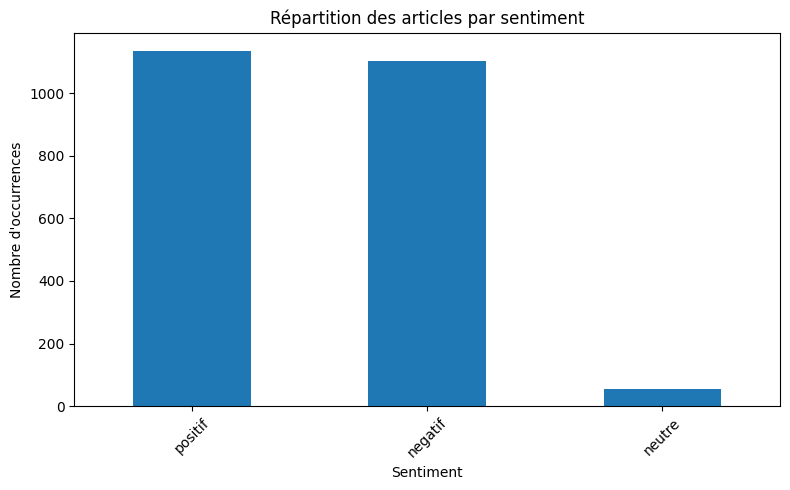

In [13]:
import matplotlib.pyplot as plt
data = list(collection.find())
df = pd.DataFrame(data)
volume_sentiment = df["sentiment"].value_counts()

plt.figure(figsize=(8,5))
volume_sentiment.plot(kind="bar")

plt.title("Répartition des articles par sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

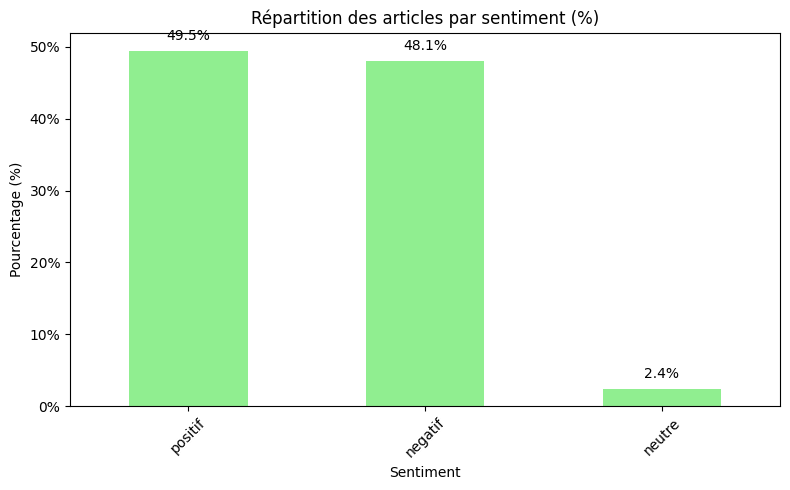

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

# Si tu récupères les données depuis MongoDB
data = list(collection.find())
df = pd.DataFrame(data)

# Comptage par sentiment
volume_sentiment = df["sentiment"].value_counts()

# Conversion en pourcentage
volume_sentiment_percent = volume_sentiment / volume_sentiment.sum()  # valeurs 0→1

# --- Graphique ---
plt.figure(figsize=(8,5))
ax = volume_sentiment_percent.plot(kind="bar", color="lightgreen")

# Formatter axe Y en %
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Ajouter les valeurs en % sur chaque barre
for i, v in enumerate(volume_sentiment_percent):
    ax.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=10)

plt.title("Répartition des articles par sentiment (%)")
plt.xlabel("Sentiment")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

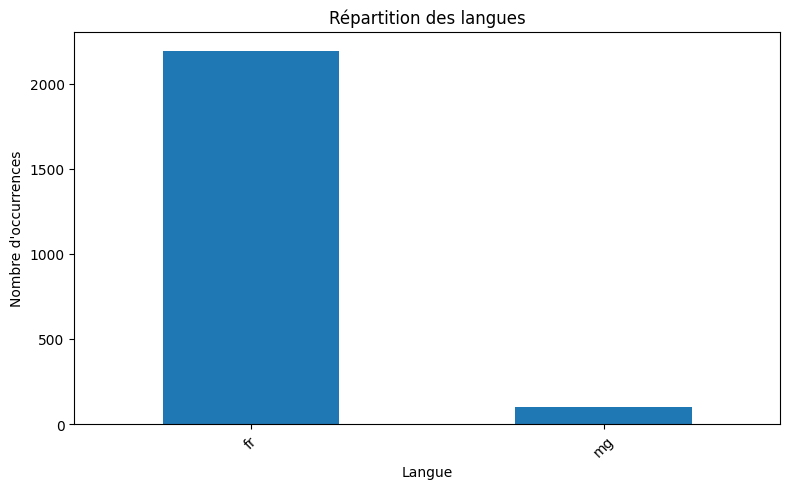

In [15]:
import matplotlib.pyplot as plt
data = list(collection.find())
df = pd.DataFrame(data)
volume_sentiment = df["langue"].value_counts()

plt.figure(figsize=(8,5))
volume_sentiment.plot(kind="bar")

plt.title("Répartition des langues")
plt.xlabel("Langue")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

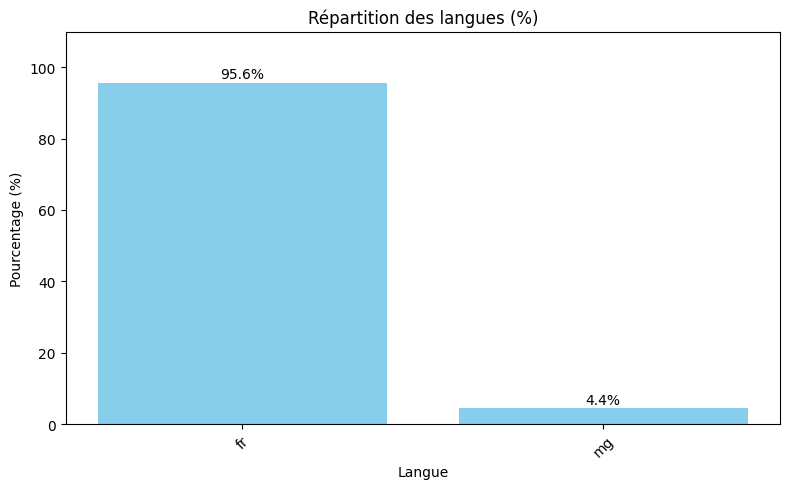

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Charger les données
data = list(collection.find())
df = pd.DataFrame(data)

# Calculer les pourcentages
volume_sentiment = df["langue"].value_counts(normalize=True) * 100  # %
labels = volume_sentiment.index
values = volume_sentiment.values

# Création du graphique
plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color="skyblue")

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height + 0.5,               # légèrement au-dessus
        f"{height:.1f}%",            # 1 chiffre après la virgule
        ha='center', va='bottom'
    )

plt.title("Répartition des langues (%)")
plt.xlabel("Langue")
plt.ylabel("Pourcentage (%)")
plt.ylim(0, max(values)*1.15)  # espace pour le texte au-dessus
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

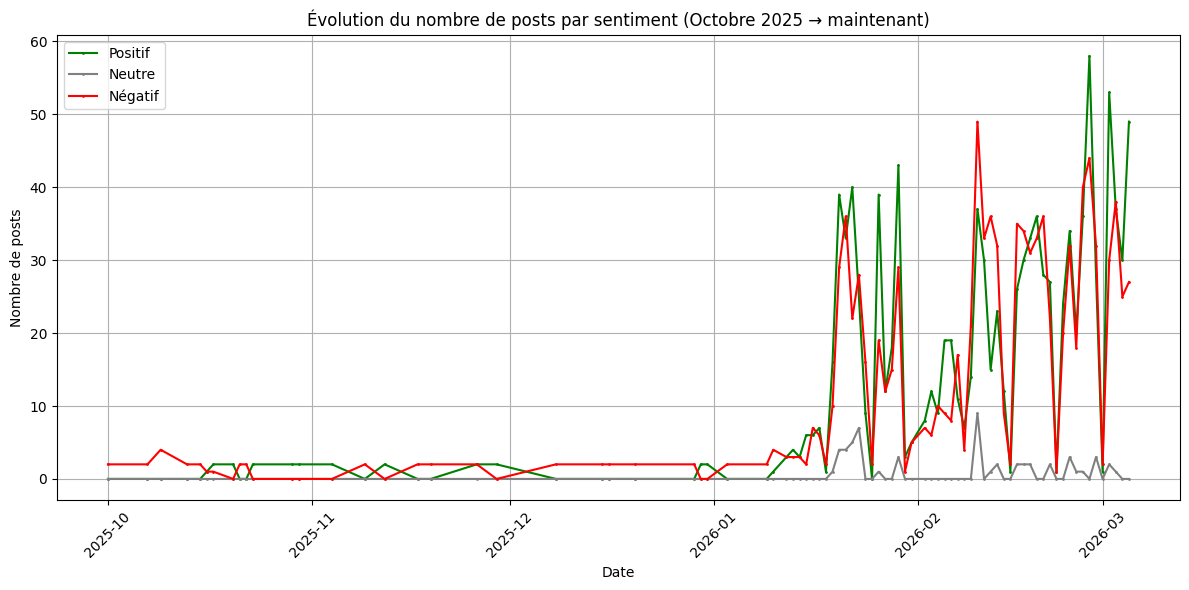

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion en datetime
df["date_publication"] = pd.to_datetime(df["date_publication"])

# Filtrer : 1er octobre 2025 à maintenant
df_filtered = df[
    (df["date_publication"] >= "2025-10-01") &
    (df["date_publication"] <= pd.Timestamp.now())
].copy()  # <- copy() pour éviter le warning

# Extraire seulement la date (sans heure)
df_filtered["date"] = df_filtered["date_publication"].dt.date

# Compter nombre de posts par sentiment par jour
df_counts = df_filtered.groupby(["date", "sentiment"]).size().unstack(fill_value=0)

# Reconvertir index en datetime pour matplotlib
df_counts.index = pd.to_datetime(df_counts.index)

# ----- GRAPHE -----
plt.figure(figsize=(12,6))

if "positif" in df_counts.columns:
    plt.plot(df_counts.index, df_counts["positif"], label="Positif", color="green", marker="o", markersize=1)
if "neutre" in df_counts.columns:
    plt.plot(df_counts.index, df_counts["neutre"], label="Neutre", color="gray", marker="o", markersize=1)
if "negatif" in df_counts.columns:
    plt.plot(df_counts.index, df_counts["negatif"], label="Négatif", color="red", marker="o", markersize=1)

plt.title("Évolution du nombre de posts par sentiment (Octobre 2025 → maintenant)")
plt.xlabel("Date")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

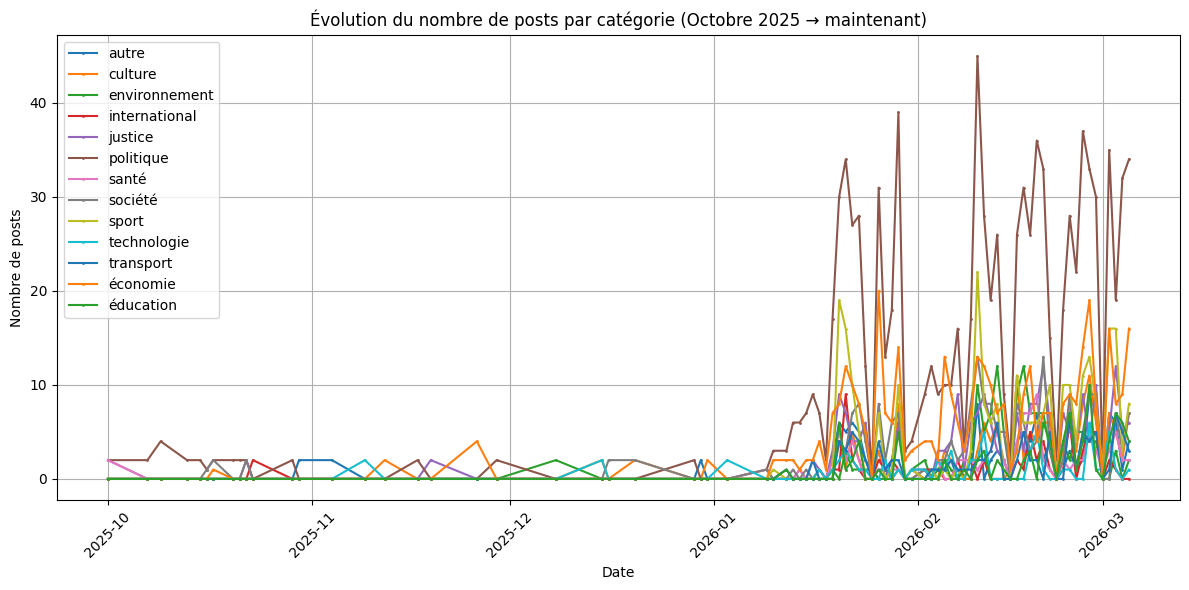

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion en datetime
df["date_publication"] = pd.to_datetime(df["date_publication"])

# Filtrer : 1er octobre 2025 à maintenant
df_filtered = df[
    (df["date_publication"] >= "2025-10-01") &
    (df["date_publication"] <= pd.Timestamp.now())
].copy()

# Extraire seulement la date (sans heure)
df_filtered["date"] = df_filtered["date_publication"].dt.date
df_filtered = df_filtered.explode("categorie")

# Compter nombre de posts par catégorie par jour
df_counts = df_filtered.groupby(["date", "categorie"]).size().unstack(fill_value=0)

# Reconvertir index en datetime pour matplotlib
df_counts.index = pd.to_datetime(df_counts.index)

# ----- GRAPHE -----
plt.figure(figsize=(12,6))

# Boucle automatique sur toutes les catégories existantes
for cat in df_counts.columns:
    plt.plot(
        df_counts.index,
        df_counts[cat],
        label=str(cat),
        marker="o",
        markersize=1
    )

plt.title("Évolution du nombre de posts par catégorie (Octobre 2025 → maintenant)")
plt.xlabel("Date")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

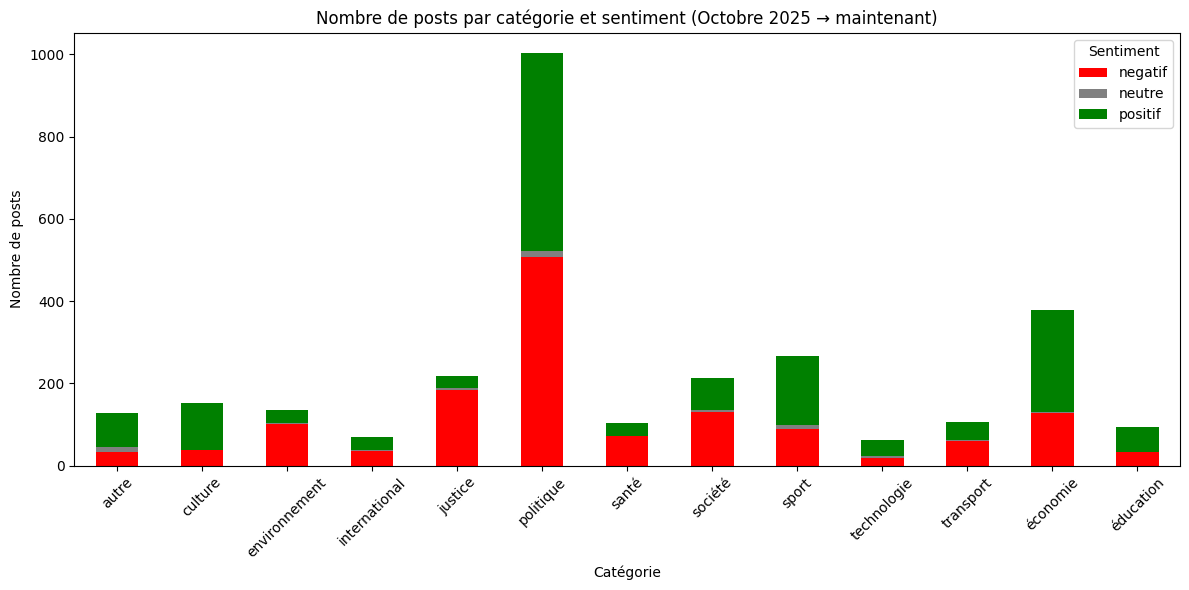

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion en datetime si ce n'est pas déjà fait
df["date_publication"] = pd.to_datetime(df["date_publication"])

# Filtrer : 1er octobre 2025 à maintenant
df_filtered = df[
    (df["date_publication"] >= "2025-10-01") &
    (df["date_publication"] <= pd.Timestamp.now())
].copy()

# Si categorie contient des listes, explode pour compter chaque catégorie individuellement
if df_filtered["categorie"].apply(lambda x: isinstance(x, list)).any():
    df_filtered = df_filtered.explode("categorie")

# Grouper par catégorie et sentiment
df_counts = df_filtered.groupby(["categorie", "sentiment"]).size().unstack(fill_value=0)

# ----- GRAPHE -----
df_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color={"positif":"green", "neutre":"gray", "negatif":"red"}
)

plt.title("Nombre de posts par catégorie et sentiment (Octobre 2025 → maintenant)")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

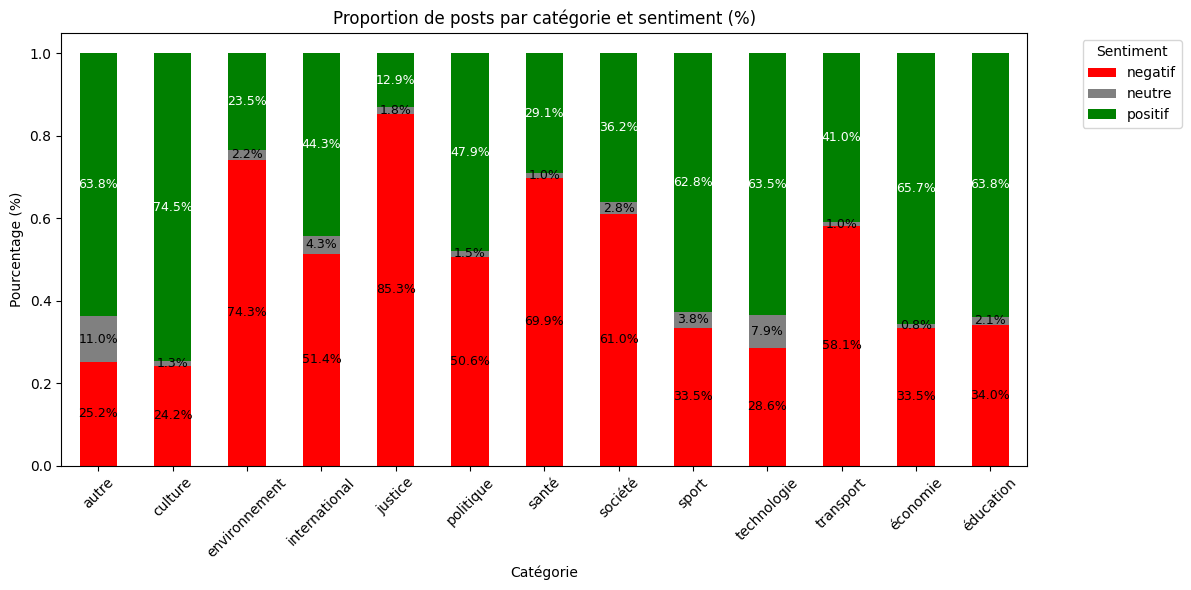

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion en datetime
df["date_publication"] = pd.to_datetime(df["date_publication"])

# Filtrer : 1er octobre 2025 à maintenant
df_filtered = df[
    (df["date_publication"] >= "2025-10-01") &
    (df["date_publication"] <= pd.Timestamp.now())
].copy()

# Si categorie contient des listes, explode pour compter chaque catégorie individuellement
if df_filtered["categorie"].apply(lambda x: isinstance(x, list)).any():
    df_filtered = df_filtered.explode("categorie")

# Grouper par catégorie et sentiment
df_counts = df_filtered.groupby(["categorie", "sentiment"]).size().unstack(fill_value=0)

# Conversion en pourcentage par catégorie (pour 100% stacked)
df_percent = df_counts.div(df_counts.sum(axis=1), axis=0)

# ----- GRAPHE -----
ax = df_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color={"positif":"green", "neutre":"gray", "negatif":"red"}
)

plt.title("Proportion de posts par catégorie et sentiment (%)")
plt.xlabel("Catégorie")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

# --- Ajouter les valeurs % sur chaque segment ---
for i, (cat, row) in enumerate(df_percent.iterrows()):
    bottom = 0
    for sentiment in df_percent.columns:
        val = row[sentiment]
        if val > 0:
            ax.text(
                i, 
                bottom + val/2,  # position au milieu du segment
                f"{val*100:.1f}%", 
                ha='center', 
                va='center', 
                fontsize=9,
                color='white' if sentiment=="positif" else 'black'
            )
            bottom += val

plt.show()

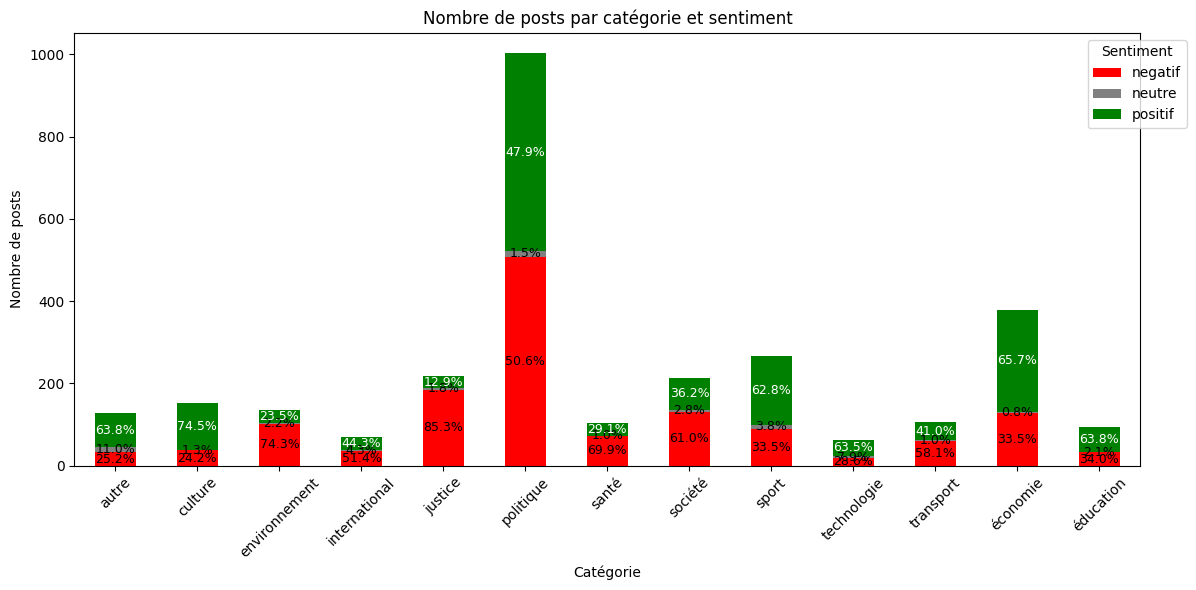

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Conversion en datetime
df["date_publication"] = pd.to_datetime(df["date_publication"])

# Filtrer : 1er octobre 2025 à maintenant
df_filtered = df[
    (df["date_publication"] >= "2025-10-01") &
    (df["date_publication"] <= pd.Timestamp.now())
].copy()

# Si categorie contient des listes, explode
if df_filtered["categorie"].apply(lambda x: isinstance(x, list)).any():
    df_filtered = df_filtered.explode("categorie")

# Grouper par catégorie et sentiment
df_counts = df_filtered.groupby(["categorie", "sentiment"]).size().unstack(fill_value=0)

# ----- GRAPHE -----
ax = df_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color={"positif":"green", "neutre":"gray", "negatif":"red"}
)

plt.title("Nombre de posts par catégorie et sentiment")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

# --- Ajouter les pourcentages sur chaque segment ---
for i, (cat, row) in enumerate(df_counts.iterrows()):
    total = row.sum()
    bottom = 0
    for sentiment in df_counts.columns:
        val = row[sentiment]
        if val > 0:
            pct = val / total * 100
            ax.text(
                i, 
                bottom + val/2,  # milieu du segment
                f"{pct:.1f}%", 
                ha='center', 
                va='center', 
                fontsize=9,
                color='white' if sentiment=="positif" else 'black'
            )
            bottom += val

plt.show()

In [18]:
print(df.isna().sum())

_id                 0
id_article          0
source              0
titre               0
date_publication    0
contenu             0
url                 0
categorie           0
sentiment           0
source_type         0
created_at          0
sentiment_score     0
langue              0
dtype: int64


In [19]:
print(df[df["contenu"].isna()][["source", "url"]])

Empty DataFrame
Columns: [source, url]
Index: []


In [17]:
df = df.dropna()

In [59]:
from pymongo import UpdateOne
from urllib.parse import urlparse

domain_to_name = {
    "2424.mg": "2424 MG",
    "lgdi-madagascar.com": "LGDI Madagascar",
    "midi-madagasikara.mg": "Midi Madagasikara",
    "namana-studio.fr": "Namana Studio",
    "newsmada.com": "News Mada",
    "rsf.org": "RSF",
    "courrierinternational.com": "Courrier International",
    "lemonde.fr": "Le Monde",
    "lexpress.mg": "L’Express",
    "madagascar-tribune.com": "Madagascar Tribune",
    "youtube.com": "YouTube",
    "Malagasy News": "Malagasy News",
    "Orange Actu": "Orange Actu"
}

def extract_origin(source):
    if source.startswith("http"):
        domain = urlparse(source).netloc
        # retirer www.
        if domain.startswith("www."):
            domain = domain[4:]
        return domain_to_name.get(domain, domain)  # si non trouvé, garde le domaine
    else:
        # sources textuelles
        return domain_to_name.get(source, source)

operations = []

for doc in collection.find({}, {"source": 1}):
    source_val = doc.get("source")
    origin_val = extract_origin(source_val)
    operations.append(
        UpdateOne(
            {"_id": doc["_id"]},
            {"$set": {"origin": origin_val}}
        )
    )

if operations:
    result = collection.bulk_write(operations)
    print(f"✅ Documents modifiés : {result.modified_count}")

✅ Documents modifiés : 0


In [60]:
for doc in collection.find({}, {"source":1, "origin":1}).limit(10):
    print(doc)

{'_id': ObjectId('696f6450803a3bd1d5076f9f'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backend', 'origin': 'Madagascar Tribune'}
{'_id': ObjectId('696f6450803a3bd1d5076fa0'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backend', 'origin': 'Madagascar Tribune'}
{'_id': ObjectId('696f6451803a3bd1d5076fa1'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backend', 'origin': 'Madagascar Tribune'}
{'_id': ObjectId('696f6451803a3bd1d5076fa2'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backend', 'origin': 'Madagascar Tribune'}
{'_id': ObjectId('696f6451803a3bd1d5076fa3'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backend', 'origin': 'Madagascar Tribune'}
{'_id': ObjectId('696f6451803a3bd1d5076fa4'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backend', 'origin': 'Madagascar Tribune'}
{'_id': ObjectId('696f6451803a3bd1d5076fa5'), 'source': 'https://www.madagascar-tribune.com/spip.php?page=backen

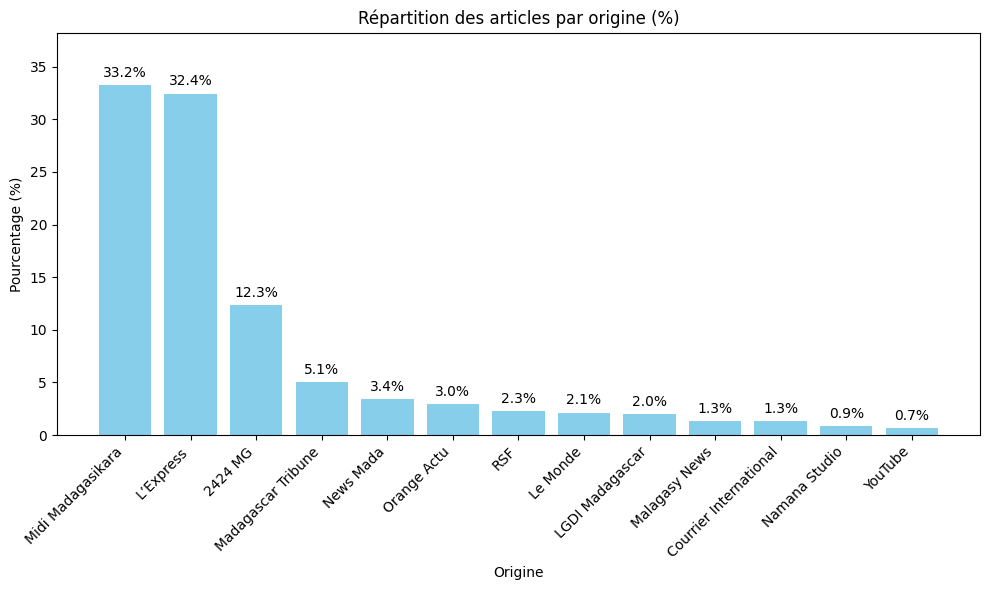

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]

# Charger toutes les données
data = list(collection.find({}, {"origin": 1}))  # juste le champ origin
df = pd.DataFrame(data)

# Compter le nombre d'articles par origin
volume_origin = df["origin"].value_counts(normalize=True) * 100  # en pourcentage
labels = volume_origin.index
values = volume_origin.values
plt.figure(figsize=(10,6))
bars = plt.bar(labels, values, color="skyblue")

# Ajouter les pourcentages sur chaque barre
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center', va='bottom'
    )

plt.title("Répartition des articles par origine (%)")
plt.xlabel("Origine")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(values)*1.15)  # espace pour le texte au-dessus
plt.tight_layout()
plt.show()

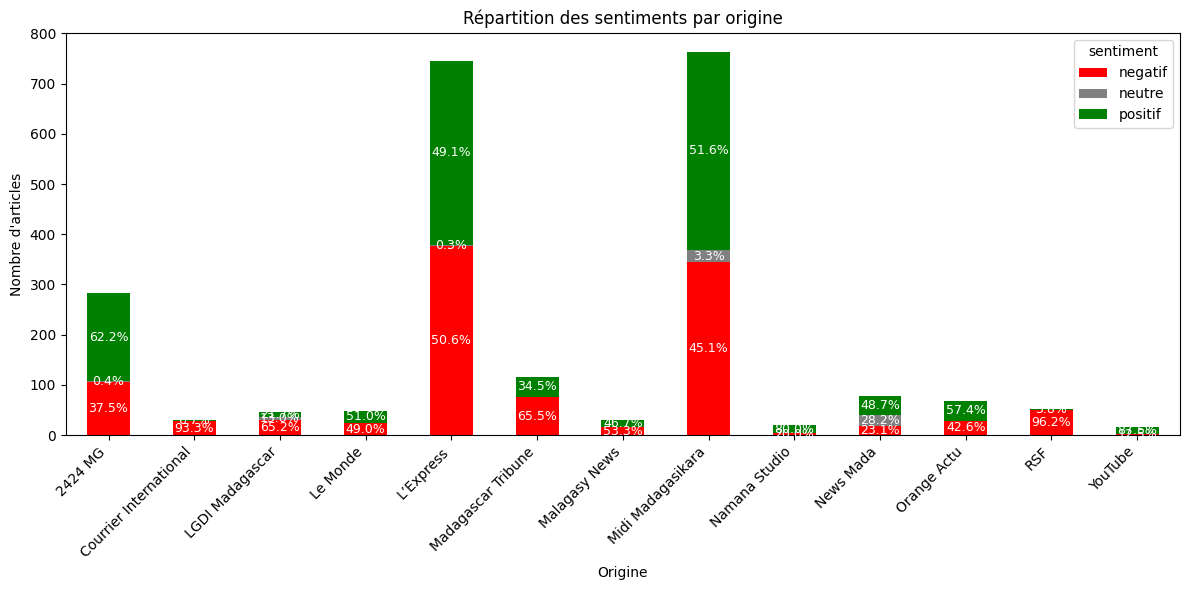

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

# Connexion MongoDB
client = MongoClient(MONGO_URI)
db = client["veille_media"]
collection = db["articles"]

# Charger les champs nécessaires
data = list(collection.find({}, {"origin": 1, "sentiment": 1}))
df = pd.DataFrame(data)
df['sentiment'] = df['sentiment'].fillna('Neutre')

# Grouper par origin et sentiment, compter le nombre d'articles
df_grouped = df.groupby(['origin', 'sentiment']).size().unstack(fill_value=0)

# Couleurs
colors = {
    "positif": "green",
    "neutre": "gray",
    "negatif": "red"
}

# Graphique empilé avec échelle réelle
ax = df_grouped.plot(
    kind='bar', 
    stacked=True, 
    color=[colors.get(x, "gray") for x in df_grouped.columns],
    figsize=(12,6)
)

# Titre et axes
plt.title("Répartition des sentiments par origine")
plt.xlabel("Origine")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45, ha='right')

# Afficher le pourcentage sur chaque segment
for i, origin in enumerate(df_grouped.index):
    total = df_grouped.loc[origin].sum()  # total articles pour cette origine
    bottom = 0
    for sentiment in df_grouped.columns:
        count = df_grouped.loc[origin, sentiment]
        if count > 0:
            percent = (count / total) * 100
            plt.text(
                i, bottom + count/2, f"{percent:.1f}%", 
                ha='center', va='center', color='white', fontsize=9
            )
            bottom += count

plt.tight_layout()
plt.show()

In [ ]:
data = list(collection.find({}, {"date_publication": 1, "origin": 1}))
df = pd.DataFrame(data)

# Conversion en datetime
df["date_publication"] = pd.to_datetime(df["date_publication"])

# Filtrer : 1er octobre 2025 à maintenant
df_filtered = df[
    (df["date_publication"] >= "2025-10-01") &
    (df["date_publication"] <= pd.Timestamp.now())
].copy()

# Extraire seulement la date (sans heure)
df_filtered["date"] = df_filtered["date_publication"].dt.date

# Si origin peut être multiple, explode (optionnel)
# df_filtered = df_filtered.explode("origin")  # seulement si c'est une liste

# Compter nombre de posts par origin par jour
df_counts = df_filtered.groupby(["date", "origin"]).size().unstack(fill_value=0)

# Reconvertir index en datetime pour matplotlib
df_counts.index = pd.to_datetime(df_counts.index)

# ----- GRAPHE -----
plt.figure(figsize=(12,6))

# Boucle automatique sur toutes les origines existantes
for orig in df_counts.columns:
    plt.plot(
        df_counts.index,
        df_counts[orig],
        label=str(orig),
        marker="o",
        markersize=1
    )

plt.title("Évolution du nombre de posts par origine (Octobre 2025 → maintenant)")
plt.xlabel("Date")
plt.ylabel("Nombre de posts")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()